# MLP feedforward

En esta notebook se intento agregar boosting, pero

. Why boosting with slim NNs tends to fail here

Key points:

Boosting assumes very weak learners.
AdaBoost/XGBoost theory works best when each base learner has high bias and low variance (e.g. depth-1 trees).
Your slim MLP is already a quite strong learner on this dataset (70 % val acc). Boosting strong learners usually increases variance and amplifies quirks of the training set.

Tiny dataset + reweighting = high variance.
At each boosting round, WeightedRandomSampler keeps sampling the same small set of “hard” points. The network quickly overfits those, harming global boundary and killing validation performance.

Multi-class, multi-task, skewed.
We’re:

In multi-class (5 labels, ~11 painters),

With class imbalance (we already use class weights),

And then add per-sample weights on top.
Effective loss weight for sample 


This often makes the loss landscape very noisy and unstable.

If you evaluated only the last learner:
By design, each new learner is trained on a highly biased (reweighted) sample. It is not supposed to be good alone; only the ensemble is meant to be good:



	​

 having ~28 % acc is absolutely plausible.

So: the fact you dropped from 70 % → 28 % is not a code “bug”, it’s telling you that this particular boosting setup is a bad fit.

In [1]:
# === Cell 0: imports & config ===

from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from scripts import style
style.mpl_apply()

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 246
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

# Load the data

In [2]:
# === Cell 1: load df ===

DATA_PATH = Path("09 features/redes_local/datos/processed/df.csv")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (200, 57)


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,pct_bright_block_2_2,H_shannon,center_mean_ratio,center_bright_ratio,lum_centroid_x,lum_centroid_y,filename,painter,genre,label
0,102.20103,105.277170,106.873116,32.077003,33.305286,33.510914,0.0,0.0,0.0,186.0,...,0.195138,-1419.565426,1.198618,1.749636,0.486834,-0.154286,Alfred_Sisley_1.jpg,Alfred_Sisley,Impresionismo,4
1,123.62030,136.959850,149.195050,46.771084,43.979904,49.263435,0.0,0.0,0.0,255.0,...,0.098290,-1419.565426,1.061136,0.937835,0.502996,-0.188640,Alfred_Sisley_10.jpg,Alfred_Sisley,Impresionismo,4
2,118.90262,116.895996,108.091415,48.649280,52.237015,61.140570,0.0,0.0,0.0,255.0,...,0.117654,-1419.489874,0.852622,1.311007,0.504956,-0.304950,Alfred_Sisley_11.jpg,Alfred_Sisley,Impresionismo,4
3,133.78065,140.773590,146.314380,36.072636,36.483162,50.136950,4.0,4.0,0.0,255.0,...,0.018207,-1419.565426,1.091522,1.702214,0.500399,-0.215292,Alfred_Sisley_12.jpg,Alfred_Sisley,Impresionismo,4
4,107.30281,108.520706,92.723560,32.748276,32.094944,37.935650,0.0,0.0,0.0,229.0,...,0.020639,-1419.565426,1.132043,2.128325,0.506062,-0.137083,Alfred_Sisley_13.jpg,Alfred_Sisley,Impresionismo,4


In [3]:
# === Cell 2: encode painter and label meta ===

# Encode painters
painter_names = sorted(df["painter"].unique())
painter_to_idx = {name: i for i, name in enumerate(painter_names)}
idx_to_painter = {i: name for name, i in painter_to_idx.items()}

df["painter_idx"] = df["painter"].map(painter_to_idx)

NUM_PAINTERS = len(painter_names)

# Labels (movement / genre index)
# Assume df["label"] is already integer-coded per genre
NUM_LABELS = df["label"].nunique()

# Derive genre names per label (sorted by label index)
label_to_genre = (
    df.drop_duplicates("label")
      .sort_values("label")
      .set_index("label")["genre"]
      .to_dict()
)
class_names = [label_to_genre[i] for i in range(NUM_LABELS)]

print("Painters:", painter_names)
print("NUM_PAINTERS:", NUM_PAINTERS)
print("NUM_LABELS:", NUM_LABELS)
print("Labels → genres:", label_to_genre)


Painters: ['Alfred_Sisley', 'Camille_Pissarro', 'Caravaggio', 'Claude_Monet', 'Jackson_Pollock', 'Joan_Miro', 'Pablo_Picasso', 'Rembrandt', 'Rene_Magritte', 'Salvador_Dali', 'Vincent_van_Gogh']
NUM_PAINTERS: 11
NUM_LABELS: 5
Labels → genres: {0: 'Surrealismo', 1: 'Cubismo', 2: 'Expresionismo abstracto', 3: 'Barroco', 4: 'Impresionismo'}


In [4]:
# === Cell 3: build feature matrix and targets ===

meta_cols = ["filename", "painter", "genre", "label", "painter_idx"]

feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].to_numpy(dtype=np.float32)
y_painter = df["painter_idx"].to_numpy(dtype=np.int64)
y_label   = df["label"].to_numpy(dtype=np.int64)

print("X shape:", X.shape)
print("y_painter shape:", y_painter.shape)
print("y_label shape:", y_label.shape)
print("Painter counts:", np.bincount(y_painter))
print("Label counts:",   np.bincount(y_label))


X shape: (200, 53)
y_painter shape: (200,)
y_label shape: (200,)
Painter counts: [20 10 10 30 15 20 30 20 10 20 15]
Label counts: [50 30 15 30 75]


# Train test

In [5]:
# === Cell 4: train / validation split (no test split here) ===

X_train, X_val, y_p_train, y_p_val, y_l_train, y_l_val = train_test_split(
    X,
    y_painter,
    y_label,
    test_size=0.2,           # e.g. 80% train / 20% val
    stratify=y_painter,      # stratify by painter (since painter is first task)
    random_state=SEED,
)

print("Train X:", X_train.shape)
print("Val   X:", X_val.shape)


Train X: (160, 53)
Val   X: (40, 53)


In [6]:
X_train

array([[ 1.41907257e+02,  1.39075470e+02,  1.36507874e+02, ...,
         4.46121514e-01,  5.32799423e-01, -2.56943226e-01],
       [ 6.97477646e+01,  7.00703278e+01,  6.18691444e+01, ...,
         8.61458033e-02,  5.11515260e-01, -1.43342748e-01],
       [ 1.40600204e+02,  1.30780518e+02,  1.33177841e+02, ...,
         1.88875473e+00,  4.96803492e-01, -1.65843055e-01],
       ...,
       [ 1.80752945e+02,  1.62610611e+02,  1.25758064e+02, ...,
         2.97656822e+00,  4.85407472e-01, -2.03997046e-01],
       [ 1.36871262e+02,  1.28774048e+02,  6.00474663e+01, ...,
         1.28136408e+00,  4.49705392e-01, -3.17824811e-01],
       [ 7.28451691e+01,  6.59475403e+01,  4.56472626e+01, ...,
         1.78031492e+00,  5.34889638e-01, -1.64252132e-01]], dtype=float32)

In [7]:
# === Cell 5: scaling ===

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)


# PyTorch

In [8]:
# === Cell 6: tensors & dataloaders (multi-target) ===

BATCH_SIZE = 32

X_train_t = torch.from_numpy(X_train_scaled).float()
y_p_train_t = torch.from_numpy(y_p_train).long()
y_l_train_t = torch.from_numpy(y_l_train).long()

X_val_t = torch.from_numpy(X_val_scaled).float()
y_p_val_t = torch.from_numpy(y_p_val).long()
y_l_val_t = torch.from_numpy(y_l_val).long()

train_ds = TensorDataset(X_train_t, y_p_train_t, y_l_train_t)
val_ds   = TensorDataset(X_val_t,   y_p_val_t,   y_l_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(val_loader)


(5, 2)

In [9]:
# === Cell 7: class weights for imbalance ===

# Painter weights
painter_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_PAINTERS),
    y=y_p_train,
)

# Label weights (genre / movement)
label_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=y_l_train,
)

print("Painter class weights:", painter_class_weights)
print("Label   class weights:", label_class_weights)

painter_class_weights_t = torch.tensor(painter_class_weights, dtype=torch.float32, device=device)
label_class_weights_t   = torch.tensor(label_class_weights,   dtype=torch.float32, device=device)


Painter class weights: [0.90909091 1.81818182 1.81818182 0.60606061 1.21212121 0.90909091
 0.60606061 0.90909091 1.81818182 0.90909091 1.21212121]
Label   class weights: [0.8        1.33333333 2.66666667 1.33333333 0.53333333]


# Training

In [10]:
# === Cell 8: multi-task MLP definition ===

class MultiTaskMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims=(128, 64),
        num_painters: int = NUM_PAINTERS,
        num_labels: int = NUM_LABELS,
        dropout_p: float = 0.3,
    ):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            prev_dim = h

        self.shared = nn.Sequential(*layers)
        self.painter_head = nn.Linear(prev_dim, num_painters)
        self.label_head   = nn.Linear(prev_dim, num_labels)

    def forward(self, x: torch.Tensor):
        z = self.shared(x)
        painter_logits = self.painter_head(z)
        label_logits   = self.label_head(z)
        return painter_logits, label_logits


## Slim More dropout

In [11]:
import torch.nn as nn

class MultiTaskMLP_Slim(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        bottleneck: int = 16,     # strong bottleneck
        hidden_first: int = 32,
        dropout_p: float = 0.5,
    ):
        super().__init__()

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.BatchNorm1d(hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_first, bottleneck),
            nn.Tanh(),             # squash → smaller effective range
            nn.Dropout(dropout_p),
        )

        self.painter_head = nn.Linear(bottleneck, num_painters)
        self.label_head   = nn.Linear(bottleneck, num_labels)

    def forward(self, x: torch.Tensor):
        h = self.trunk(x)
        painter_logits = self.painter_head(h)
        label_logits   = self.label_head(h)
        return painter_logits, label_logits





## RBF

In [12]:
from sklearn.cluster import KMeans

N_RBF = 32    # number of RBF centers; keep small (10–40)
kmeans = KMeans(n_clusters=N_RBF, random_state=SEED)
kmeans.fit(X_train_scaled)   # shape (n_train, d)

centers = torch.from_numpy(kmeans.cluster_centers_).float().to(device)


c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [13]:
class RBFLayer(nn.Module):
    def __init__(self, centers: torch.Tensor, gamma: float = 1.0):
        """
        centers: (K, D) tensor (fixed)
        gamma: 1/(2*sigma^2); controls width of RBFs
        """
        super().__init__()
        self.centers = nn.Parameter(centers, requires_grad=False)
        self.gamma = nn.Parameter(torch.tensor(gamma, dtype=torch.float32), requires_grad=False)

    def forward(self, x: torch.Tensor):
        # x: (B, D), centers: (K, D)
        # Compute squared distances: (B, K)
        # ||x - c||^2 = (x^2).sum + (c^2).sum - 2 x·c
        x2 = (x ** 2).sum(dim=1, keepdim=True)              # (B, 1)
        c2 = (self.centers ** 2).sum(dim=1).unsqueeze(0)    # (1, K)
        xc = x @ self.centers.t()                           # (B, K)
        dist2 = x2 + c2 - 2 * xc
        # RBF activations
        phi = torch.exp(-self.gamma * dist2)
        return phi


In [14]:
class MultiTaskMLP_RBF(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        centers: torch.Tensor,
        hidden_first: int = 32,
        dropout_p: float = 0.4,
        gamma: float = 1.0,
    ):
        super().__init__()

        # Linear pre-transform to "RBF space"
        self.pre = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )

        self.rbf = RBFLayer(centers, gamma=gamma)  # output dim = N_RBF

        rbf_dim = centers.shape[0]

        self.painter_head = nn.Sequential(
            nn.Linear(rbf_dim, num_painters),
        )
        self.label_head   = nn.Sequential(
            nn.Linear(rbf_dim, num_labels),
        )

    def forward(self, x: torch.Tensor):
        h = self.pre(x)
        phi = self.rbf(h)
        painter_logits = self.painter_head(phi)
        label_logits   = self.label_head(phi)
        return painter_logits, label_logits


In [15]:
import torch
import torch.nn as nn

class RBFLayerLearnable(nn.Module):
    def __init__(self, in_dim: int, num_centers: int, init_gamma: float = 1.0):
        """
        in_dim:      dimensionality of the input to this RBF layer (e.g. hidden_first)
        num_centers: number of RBF units K
        init_gamma:  initial gamma; effective RBF is exp(-gamma * ||x - c||^2)
        """
        super().__init__()
        self.in_dim = in_dim
        self.num_centers = num_centers

        # Centers are learnable parameters: (K, D)
        self.centers = nn.Parameter(
            0.1 * torch.randn(num_centers, in_dim)  # small random init
        )

        # Learnable log-gamma so that gamma stays > 0
        self.log_gamma = nn.Parameter(
            torch.log(torch.tensor(init_gamma, dtype=torch.float32))
        )

    def forward(self, x: torch.Tensor):
        """
        x: (B, D) where D = in_dim
        returns: (B, K) RBF activations
        """
        # ensure gamma > 0
        gamma = torch.exp(self.log_gamma)

        # x^2: (B, 1)
        x2 = (x ** 2).sum(dim=1, keepdim=True)
        # c^2: (1, K)
        c2 = (self.centers ** 2).sum(dim=1).unsqueeze(0)
        # x·c: (B, K)
        xc = x @ self.centers.t()

        # squared distance: (B, K)
        dist2 = x2 + c2 - 2 * xc

        # RBF features: (B, K)
        phi = torch.exp(-gamma * dist2)
        return phi


## RBF Learnable

In [16]:
class MultiTaskMLP_RBF_Learnable(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        hidden_first: int = 32,
        n_rbf: int = 20,
        dropout_p: float = 0.4,
        init_gamma: float = 1.0,
    ):
        super().__init__()

        # Linear + ReLU pre-transform: R^d -> R^{hidden_first}
        self.pre = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )

        # RBF layer in this hidden space: centers ∈ R^{n_rbf × hidden_first}
        self.rbf = RBFLayerLearnable(
            in_dim=hidden_first,
            num_centers=n_rbf,
            init_gamma=init_gamma,
        )

        self.dropout = nn.Dropout(dropout_p)

        # Heads see K-dimensional RBF feature vector
        self.painter_head = nn.Linear(n_rbf, num_painters)
        self.label_head   = nn.Linear(n_rbf, num_labels)

    def forward(self, x: torch.Tensor):
        # x: (B, input_dim)
        h = self.pre(x)          # (B, hidden_first)
        phi = self.rbf(h)        # (B, n_rbf)
        phi = self.dropout(phi)  # optional extra regularization

        painter_logits = self.painter_head(phi)  # (B, num_painters)
        label_logits   = self.label_head(phi)    # (B, num_labels)
        return painter_logits, label_logits


In [ ]:
iwant = "slim"
input_dim = X_train.shape[1]
def make_base_model(iwant):
    if iwant == "base":
        # usage:
        model = MultiTaskMLP(
            input_dim=input_dim,
            hidden_dims=(64, 32),
            num_painters=NUM_PAINTERS,
            num_labels=NUM_LABELS,
            dropout_p=0.3,
        )
        model.to(device)
    elif iwant == "slim":
        # usage:
        model = MultiTaskMLP_Slim(
            input_dim=input_dim,
            num_painters=NUM_PAINTERS,
            num_labels=NUM_LABELS,
            bottleneck=16,
            hidden_first=32,
            dropout_p=0.5,
        ).to(device)
    elif iwant == "rbf":
        # usage:
        model = MultiTaskMLP_RBF(
            input_dim=input_dim,
            num_painters=NUM_PAINTERS,
            num_labels=NUM_LABELS,
            centers=centers,
            hidden_first=32,
            dropout_p=0.4,
            gamma=1.0,   # tune gamma between e.g. 0.1 and 5.0
        ).to(device)
    elif iwant == "rbf_learnable":
        model = MultiTaskMLP_RBF_Learnable(
        input_dim=input_dim,
        num_painters=NUM_PAINTERS,
        num_labels=NUM_LABELS,
        hidden_first=32,   # or 16 / 64, etc.
        n_rbf=20,          # number of RBF units (capacity knob)
        dropout_p=0.4,
        init_gamma=1.0,
        ).to(device)
    else:
        raise ValueError(f"Unknown model type: {iwant}")
    return model

model = make_base_model(iwant)

In [18]:
# === Cell 9: helpers for train & eval (multi-task) ===

def train_one_epoch(
    model,
    loader,
    optimizer,
    painter_criterion,
    label_criterion,
    device,
    lambda_p: float = 1.0,
    lambda_l: float = 1.0,
):
    model.train()
    total = 0
    sum_loss = 0.0
    correct_painter = 0
    correct_label = 0

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        y_p_batch = y_p_batch.to(device)
        y_l_batch = y_l_batch.to(device)

        optimizer.zero_grad()
        painter_logits, label_logits = model(X_batch)

        painter_loss = painter_criterion(painter_logits, y_p_batch)
        label_loss   = label_criterion(label_logits,   y_l_batch)

        loss = lambda_p * painter_loss + lambda_l * label_loss
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        sum_loss += loss.item() * batch_size
        total += batch_size

        painter_pred = painter_logits.argmax(dim=1)
        label_pred   = label_logits.argmax(dim=1)

        correct_painter += (painter_pred == y_p_batch).sum().item()
        correct_label   += (label_pred   == y_l_batch).sum().item()

    epoch_loss = sum_loss / total
    painter_acc = correct_painter / total
    label_acc   = correct_label   / total
    return epoch_loss, painter_acc, label_acc


@torch.no_grad()
def evaluate(
    model,
    loader,
    painter_criterion,
    label_criterion,
    device,
    lambda_p: float = 1.0,
    lambda_l: float = 1.0,
):
    model.eval()
    total = 0
    sum_loss = 0.0
    correct_painter = 0
    correct_label = 0

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        y_p_batch = y_p_batch.to(device)
        y_l_batch = y_l_batch.to(device)

        painter_logits, label_logits = model(X_batch)

        painter_loss = painter_criterion(painter_logits, y_p_batch)
        label_loss   = label_criterion(label_logits,   y_l_batch)

        loss = lambda_p * painter_loss + lambda_l * label_loss

        batch_size = X_batch.size(0)
        sum_loss += loss.item() * batch_size
        total += batch_size

        painter_pred = painter_logits.argmax(dim=1)
        label_pred   = label_logits.argmax(dim=1)

        correct_painter += (painter_pred == y_p_batch).sum().item()
        correct_label   += (label_pred   == y_l_batch).sum().item()

    epoch_loss = sum_loss / total
    painter_acc = correct_painter / total
    label_acc   = correct_label   / total
    return epoch_loss, painter_acc, label_acc


# Boosted Ensemble

In [19]:
from torch.utils.data import DataLoader, WeightedRandomSampler

def train_boosted_ensemble(
    X_train_t: torch.Tensor,
    y_p_train_t: torch.Tensor,
    y_l_train_t: torch.Tensor,
    num_rounds: int,
    base_epochs: int,
    batch_size: int,
    painter_criterion,
    label_criterion,
    lambda_p: float,
    lambda_l: float,
):
    """
    Returns:
        models: list of trained base models
        alphas: list of model weights (one per round)
    """
    N = X_train_t.shape[0]

    # initial sample weights: uniform
    w = np.ones(N, dtype=np.float64) / N

    models = []
    alphas = []

    for m in range(num_rounds):
        print(f"\n=== Boosting round {m+1}/{num_rounds} ===")

        # --- sampler using current sample weights
        sampler = WeightedRandomSampler(
            weights=torch.from_numpy(w).float(),
            num_samples=N,  # same size, with replacement
            replacement=True,
        )

        train_ds = TensorDataset(X_train_t, y_p_train_t, y_l_train_t)
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)

        # fresh base model
        model = make_base_model(iwant)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

        # train base model for a few epochs on weighted data
        for epoch in range(1, base_epochs + 1):
            train_loss, train_p_acc, train_l_acc = train_one_epoch(
                model,
                train_loader,
                optimizer,
                painter_criterion,
                label_criterion,
                device,
                lambda_p=lambda_p,
                lambda_l=lambda_l,
            )
            print(
                f"  [round {m+1}] epoch {epoch}/{base_epochs} "
                f"loss={train_loss:.4f}, p_acc={train_p_acc:.3f}, l_acc={train_l_acc:.3f}"
            )

        # --- compute weighted error on FULL train set (no sampler)
        model.eval()
        with torch.no_grad():
            X_all = X_train_t.to(device)
            p_logits, l_logits = model(X_all)
            y_l_pred = l_logits.argmax(dim=1).cpu().numpy()  # focus on labels for error
            y_l_true = y_l_train_t.numpy()

        mis = (y_l_pred != y_l_true).astype(np.float64)  # 1 if misclassified

        # weighted error
        eps = 1e-10
        e_m = (w * mis).sum() / w.sum()
        e_m = np.clip(e_m, eps, 1 - eps)  # avoid division by 0 / inf

        alpha_m = math.log((1.0 - e_m) / e_m)
        print(f"  weighted error e_m={e_m:.4f}, alpha_m={alpha_m:.4f}")

        # if e_m >= 0.5, boosting is not helpful; break
        if e_m >= 0.5:
            print("  e_m >= 0.5; stopping boosting.")
            break

        # update sample weights
        w = w * np.exp(alpha_m * mis)
        w = w / w.sum()  # normalize

        models.append(model)
        alphas.append(alpha_m)

    return models, alphas


In [24]:
painter_criterion = nn.CrossEntropyLoss(weight=painter_class_weights_t)
label_criterion   = nn.CrossEntropyLoss(weight=label_class_weights_t)
LAMBDA_P = 1.0
LAMBDA_L = 1.0

models, alphas = train_boosted_ensemble(
    X_train_t=X_train_t,
    y_p_train_t=y_p_train_t,
    y_l_train_t=y_l_train_t,
    num_rounds=5,        # small, start with 3–5
    base_epochs=200,      # few epochs per round
    batch_size=BATCH_SIZE,
    painter_criterion=painter_criterion,
    label_criterion=label_criterion,
    lambda_p=LAMBDA_P,
    lambda_l=LAMBDA_L,
)



=== Boosting round 1/5 ===
  [round 1] epoch 1/200 loss=4.0199, p_acc=0.037, l_acc=0.131
  [round 1] epoch 2/200 loss=4.0328, p_acc=0.069, l_acc=0.106
  [round 1] epoch 3/200 loss=4.0040, p_acc=0.037, l_acc=0.200
  [round 1] epoch 4/200 loss=3.9903, p_acc=0.037, l_acc=0.212
  [round 1] epoch 5/200 loss=3.9673, p_acc=0.081, l_acc=0.231
  [round 1] epoch 6/200 loss=3.9126, p_acc=0.081, l_acc=0.338
  [round 1] epoch 7/200 loss=3.9390, p_acc=0.081, l_acc=0.250
  [round 1] epoch 8/200 loss=3.9077, p_acc=0.081, l_acc=0.344
  [round 1] epoch 9/200 loss=3.9006, p_acc=0.106, l_acc=0.312
  [round 1] epoch 10/200 loss=3.8572, p_acc=0.050, l_acc=0.375
  [round 1] epoch 11/200 loss=3.8023, p_acc=0.106, l_acc=0.412
  [round 1] epoch 12/200 loss=3.8014, p_acc=0.069, l_acc=0.362
  [round 1] epoch 13/200 loss=3.8089, p_acc=0.094, l_acc=0.362
  [round 1] epoch 14/200 loss=3.7082, p_acc=0.100, l_acc=0.419
  [round 1] epoch 15/200 loss=3.7907, p_acc=0.100, l_acc=0.369
  [round 1] epoch 16/200 loss=3.7614

In [25]:
@torch.no_grad()
def boosted_predict(
    models,
    alphas,
    X_t: torch.Tensor,
    device,
):
    """
    Returns:
        y_p_pred: painter predictions
        y_l_pred: label predictions
    """
    X_t = X_t.to(device)
    M = len(models)

    # accumulate weighted logits
    p_logits_sum = None
    l_logits_sum = None

    for model, alpha in zip(models, alphas):
        model.eval()
        p_logits, l_logits = model(X_t)
        if p_logits_sum is None:
            p_logits_sum = alpha * p_logits
            l_logits_sum = alpha * l_logits
        else:
            p_logits_sum += alpha * p_logits
            l_logits_sum += alpha * l_logits

    y_p_pred = p_logits_sum.argmax(dim=1).cpu().numpy()
    y_l_pred = l_logits_sum.argmax(dim=1).cpu().numpy()
    return y_p_pred, y_l_pred


In [ ]:
y_p_true = y_p_val_t.numpy()
y_l_true = y_l_val_t.numpy()

y_p_pred_ens, y_l_pred_ens = boosted_predict(
    models,
    alphas,
    X_val_t,
    device,
)

from sklearn.metrics import accuracy_score, classification_report

print("Ensemble painter acc (val):", accuracy_score(y_p_true, y_p_pred_ens))
print("Ensemble label   acc (val):", accuracy_score(y_l_true, y_l_pred_ens))

print("\nEnsemble label classification report:")
print(classification_report(y_l_true, y_l_pred_ens, target_names=class_names, digits=3))


Ensemble painter acc (val): 0.275
Ensemble label   acc (val): 0.6

Ensemble label classification report:
                         precision    recall  f1-score   support

            Surrealismo      0.000     0.000     0.000        10
                Cubismo      0.667     0.333     0.444         6
Expresionismo abstracto      1.000     0.667     0.800         3
                Barroco      0.300     1.000     0.462         6
          Impresionismo      0.933     0.933     0.933        15

               accuracy                          0.600        40
              macro avg      0.580     0.587     0.528        40
           weighted avg      0.570     0.600     0.546        40



c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


: 

In [ ]:

painter_acc = accuracy_score(y_p_true, y_p_pred)
print(f"Val painter accuracy: {painter_acc:.3f}")
print("\nPainter classification report (val):")
print(classification_report(y_p_true, y_p_pred, target_names=painter_names, digits=3))

In [ ]:
# === Cell 10: training loop (multi-task) ===

EPOCHS = 1000
LR = 1e-3
WEIGHT_DECAY = 1e-4

painter_criterion = nn.CrossEntropyLoss(weight=painter_class_weights_t)
label_criterion   = nn.CrossEntropyLoss(weight=label_class_weights_t)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

LAMBDA_P = 1.0   # weight for painter loss
LAMBDA_L = 1.0   # weight for label loss

history = {
    "train_loss": [],
    "train_painter_acc": [],
    "train_label_acc": [],
    "val_loss": [],
    "val_painter_acc": [],
    "val_label_acc": [],
}

best_val_score = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_p_acc, train_l_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        painter_criterion,
        label_criterion,
        device,
        lambda_p=LAMBDA_P,
        lambda_l=LAMBDA_L,
    )

    val_loss, val_p_acc, val_l_acc = evaluate(
        model,
        val_loader,
        painter_criterion,
        label_criterion,
        device,
        lambda_p=LAMBDA_P,
        lambda_l=LAMBDA_L,
    )

    history["train_loss"].append(train_loss)
    history["train_painter_acc"].append(train_p_acc)
    history["train_label_acc"].append(train_l_acc)
    history["val_loss"].append(val_loss)
    history["val_painter_acc"].append(val_p_acc)
    history["val_label_acc"].append(val_l_acc)

    # Use sum of accuracies as selection score (or choose one)
    val_score = 0.5 * (val_p_acc + val_l_acc)

    if val_score > best_val_score:
        best_val_score = val_score
        best_state = model.state_dict()

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}, train_p={train_p_acc:.3f}, train_l={train_l_acc:.3f} | "
        f"val_loss={val_loss:.4f}, val_p={val_p_acc:.3f}, val_l={val_l_acc:.3f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)


Epoch 01/1000 | train_loss=0.9714, train_p=0.633, train_l=0.950 | val_loss=2.3494, val_p=0.600, val_l=0.800
Epoch 02/1000 | train_loss=1.1475, train_p=0.611, train_l=0.917 | val_loss=2.3404, val_p=0.600, val_l=0.800
Epoch 03/1000 | train_loss=1.0300, train_p=0.667, train_l=0.906 | val_loss=2.3278, val_p=0.600, val_l=0.800
Epoch 04/1000 | train_loss=1.1421, train_p=0.606, train_l=0.900 | val_loss=2.3410, val_p=0.600, val_l=0.800
Epoch 05/1000 | train_loss=1.1041, train_p=0.589, train_l=0.906 | val_loss=2.3324, val_p=0.600, val_l=0.800
Epoch 06/1000 | train_loss=0.8920, train_p=0.689, train_l=0.961 | val_loss=2.3431, val_p=0.600, val_l=0.800
Epoch 07/1000 | train_loss=1.1601, train_p=0.606, train_l=0.889 | val_loss=2.3484, val_p=0.600, val_l=0.800
Epoch 08/1000 | train_loss=1.1437, train_p=0.589, train_l=0.917 | val_loss=2.3714, val_p=0.600, val_l=0.800
Epoch 09/1000 | train_loss=1.0611, train_p=0.661, train_l=0.956 | val_loss=2.3736, val_p=0.600, val_l=0.800
Epoch 10/1000 | train_loss=0

# Visualization

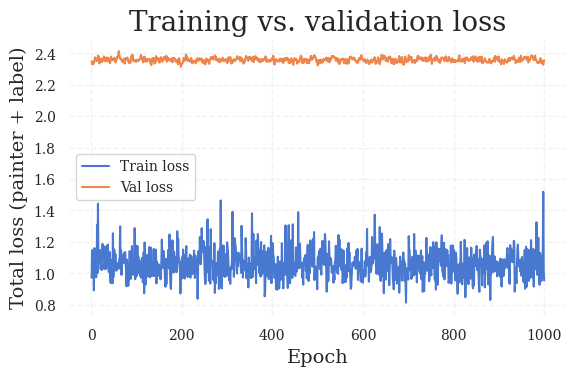

In [40]:
# === Cell 11: loss curves ===

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Total loss (painter + label)")
plt.title("Training vs. validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [41]:
# === Cell 14: prediction helper for a loader ===

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_y_p = []
    all_y_l = []
    all_p_logits = []
    all_l_logits = []

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        p_logits, l_logits = model(X_batch)

        all_y_p.append(y_p_batch)
        all_y_l.append(y_l_batch)
        all_p_logits.append(p_logits.cpu())
        all_l_logits.append(l_logits.cpu())

    y_p_true = torch.cat(all_y_p).numpy()
    y_l_true = torch.cat(all_y_l).numpy()
    p_logits = torch.cat(all_p_logits)
    l_logits = torch.cat(all_l_logits)

    y_p_pred = p_logits.argmax(dim=1).numpy()
    y_l_pred = l_logits.argmax(dim=1).numpy()

    return y_p_true, y_l_true, y_p_pred, y_l_pred


## Painter

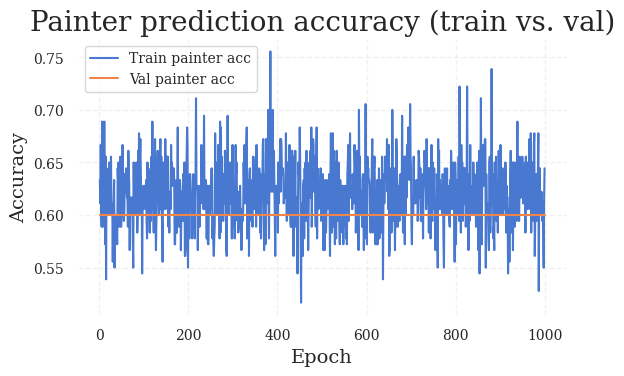

In [42]:
# === Cell 12: painter accuracy curves ===

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_painter_acc"], label="Train painter acc")
plt.plot(epochs, history["val_painter_acc"],   label="Val painter acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Painter prediction accuracy (train vs. val)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [43]:
# === Cell 15: metrics on validation set ===

y_p_true, y_l_true, y_p_pred, y_l_pred = predict_loader(model, val_loader, device)

# Painters
painter_acc = accuracy_score(y_p_true, y_p_pred)
print(f"Val painter accuracy: {painter_acc:.3f}")
print("\nPainter classification report (val):")
print(classification_report(y_p_true, y_p_pred, target_names=painter_names, digits=3))

Val painter accuracy: 0.600

Painter classification report (val):
                  precision    recall  f1-score   support

   Alfred_Sisley      0.000     0.000     0.000         2
Camille_Pissarro      0.000     0.000     0.000         1
      Caravaggio      0.500     1.000     0.667         1
    Claude_Monet      0.500     0.333     0.400         3
 Jackson_Pollock      1.000     1.000     1.000         2
       Joan_Miro      0.500     0.500     0.500         2
   Pablo_Picasso      0.500     0.333     0.400         3
       Rembrandt      1.000     1.000     1.000         2
   Rene_Magritte      1.000     1.000     1.000         1
   Salvador_Dali      0.667     1.000     0.800         2
Vincent_van_Gogh      0.333     1.000     0.500         1

        accuracy                          0.600        20
       macro avg      0.545     0.652     0.570        20
    weighted avg      0.558     0.600     0.558        20



c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


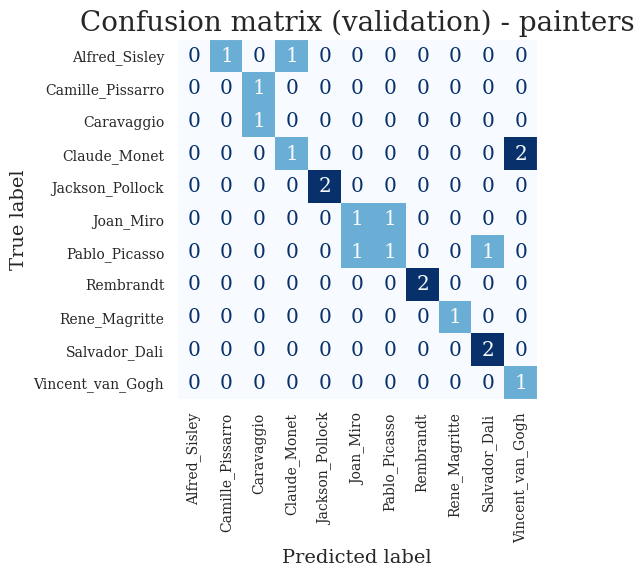

In [44]:
# === Cell 16: confusion matrix for labels (val) ===

cm_label = confusion_matrix(y_p_true, y_p_pred)

painter_names = sorted(df["painter"].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm_label, display_labels=painter_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) - painters")
plt.tight_layout()
plt.grid(False)
plt.show()


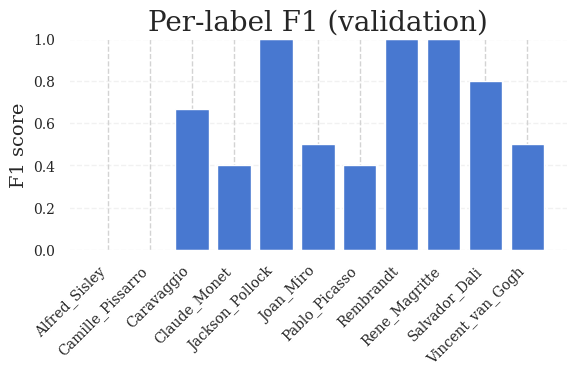

Alfred_Sisley                 : F1 = 0.000
Camille_Pissarro              : F1 = 0.000
Caravaggio                    : F1 = 0.667
Claude_Monet                  : F1 = 0.400
Jackson_Pollock               : F1 = 1.000
Joan_Miro                     : F1 = 0.500
Pablo_Picasso                 : F1 = 0.400
Rembrandt                     : F1 = 1.000
Rene_Magritte                 : F1 = 1.000
Salvador_Dali                 : F1 = 0.800
Vincent_van_Gogh              : F1 = 0.500


In [45]:
# === Cell 17: per-class F1 for labels ===

f1_per_painter = f1_score(
    y_p_true,
    y_p_pred,
    average=None,
    labels=np.arange(NUM_PAINTERS),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_PAINTERS), f1_per_painter)
plt.xticks(range(NUM_PAINTERS), painter_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-label F1 (validation)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1_val in zip(painter_names, f1_per_painter):
    print(f"{name:30s}: F1 = {f1_val:.3f}")


## Genre

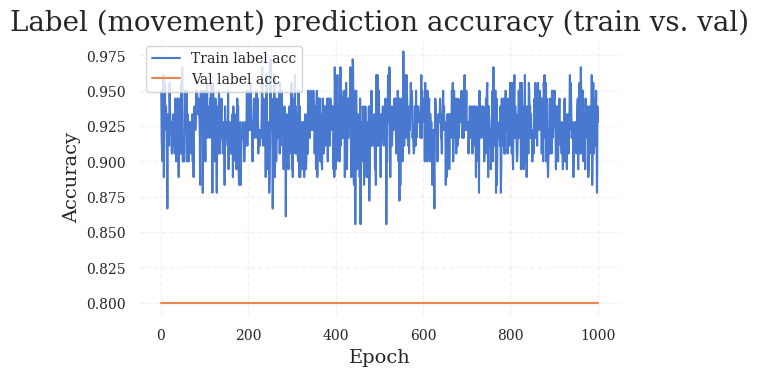

In [46]:
# === Cell 13: label accuracy curves ===

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_label_acc"], label="Train label acc")
plt.plot(epochs, history["val_label_acc"],   label="Val label acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Label (movement) prediction accuracy (train vs. val)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [47]:

# Labels (genres)
label_acc = accuracy_score(y_l_true, y_l_pred)
print(f"\nVal label accuracy: {label_acc:.3f}")
print("\nLabel (genre) classification report (val):")
print(classification_report(y_l_true, y_l_pred, target_names=class_names, digits=3))



Val label accuracy: 0.800

Label (genre) classification report (val):
                         precision    recall  f1-score   support

            Surrealismo      0.667     0.800     0.727         5
                Cubismo      0.500     0.333     0.400         3
Expresionismo abstracto      1.000     1.000     1.000         2
                Barroco      0.750     1.000     0.857         3
          Impresionismo      1.000     0.857     0.923         7

               accuracy                          0.800        20
              macro avg      0.783     0.798     0.781        20
           weighted avg      0.804     0.800     0.793        20



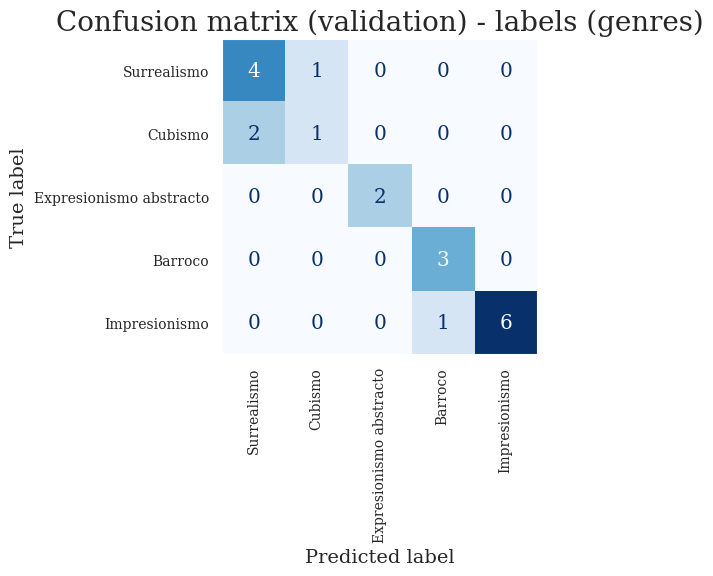

In [48]:
# === Cell 16: confusion matrix for labels (val) ===

cm_label = confusion_matrix(y_l_true, y_l_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_label, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) - labels (genres)")
plt.tight_layout()
plt.grid(False)
plt.show()


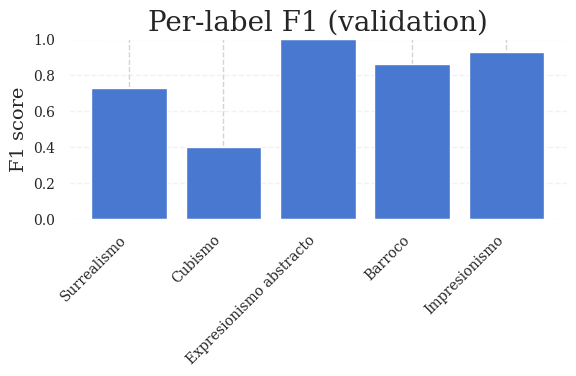

Surrealismo                   : F1 = 0.727
Cubismo                       : F1 = 0.400
Expresionismo abstracto       : F1 = 1.000
Barroco                       : F1 = 0.857
Impresionismo                 : F1 = 0.923


In [49]:
# === Cell 17: per-class F1 for labels ===

f1_per_label = f1_score(
    y_l_true,
    y_l_pred,
    average=None,
    labels=np.arange(NUM_LABELS),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_LABELS), f1_per_label)
plt.xticks(range(NUM_LABELS), class_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-label F1 (validation)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1_val in zip(class_names, f1_per_label):
    print(f"{name:30s}: F1 = {f1_val:.3f}")


# Test

In [50]:
TEST_PATH = Path("09 features/redes_local/datos/processed/df_test.csv")


In [51]:
# === Cell 18: load test df and predict (when df_test is available) ===

TEST_PATH = Path("09 features/redes_local/datos/processed/df_bb.csv")
df_test = pd.read_csv(TEST_PATH)

# Map painters with the *training* mapping
df_test["painter_idx"] = df_test["painter"].map(painter_to_idx)

# Optionally handle unknown painters
mask_unknown = df_test["painter_idx"].isna()
if mask_unknown.any():
    print("Warning: unknown painters in test:", df_test.loc[mask_unknown, "painter"].unique())
    df_test = df_test.loc[~mask_unknown].copy()

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
X_test_scaled = scaler.transform(X_test)

X_test_t = torch.from_numpy(X_test_scaled).float().to(device)

with torch.no_grad():
    p_logits_test, l_logits_test = model(X_test_t)
    y_p_pred_test = p_logits_test.argmax(dim=1).cpu().numpy()
    y_l_pred_test = l_logits_test.argmax(dim=1).cpu().numpy()

df_test["painter_pred"] = [idx_to_painter[i] for i in y_p_pred_test]
df_test["label_pred"]   = y_l_pred_test
df_test["genre_pred"]   = [class_names[i] for i in y_l_pred_test]

df_test.head()


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,lum_centroid_x,lum_centroid_y,filename,painter,genre,label,painter_idx,painter_pred,label_pred,genre_pred
0,113.894936,127.379160,103.34666,53.270428,70.752464,75.454780,0.0,2.0,0.0,255.0,...,0.553279,-0.467646,Alfred_Sisley_001.jpg,Alfred_Sisley,Impresionismo,4,0,Camille_Pissarro,4,Impresionismo
1,100.800140,91.574240,75.35645,76.134636,75.270805,72.747894,5.0,8.0,0.0,255.0,...,0.525715,-0.609516,Alfred_Sisley_002.jpg,Alfred_Sisley,Impresionismo,4,0,Caravaggio,3,Barroco
2,129.785230,116.044860,89.18722,47.168243,54.259525,42.555046,49.0,28.0,20.0,255.0,...,0.483567,-0.700687,Alfred_Sisley_003.jpg,Alfred_Sisley,Impresionismo,4,0,Camille_Pissarro,4,Impresionismo
3,119.764275,126.478325,115.54521,55.139767,62.966022,80.313644,10.0,1.0,0.0,255.0,...,0.492189,-0.565718,Alfred_Sisley_004.jpg,Alfred_Sisley,Impresionismo,4,0,Vincent_van_Gogh,4,Impresionismo
4,143.549220,138.841380,130.06557,87.223040,88.330170,91.912506,3.0,7.0,0.0,255.0,...,0.511623,-0.144344,Alfred_Sisley_005.jpg,Alfred_Sisley,Impresionismo,4,0,Camille_Pissarro,4,Impresionismo


In [52]:
X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_painter_test = df_test["painter_idx"].to_numpy(dtype=np.int64)
y_label_test = df_test["label"].to_numpy(dtype=np.int64)

print("X_test shape:", X_test.shape)
print("y_painter_test shape:", y_painter_test.shape)
print("y_label_test shape:", y_label_test.shape)
print("Painter counts:", np.bincount(y_painter_test))
print("Label counts:",   np.bincount(y_label_test))

X_test shape: (750, 53)
y_painter_test shape: (750,)
y_label_test shape: (750,)
Painter counts: [70 60 60 80 65 70 80 70 60 70 65]
Label counts: [200  80  65 130 275]


In [53]:
X_test_scaled = scaler.transform(X_test)

In [54]:
X_test_t = torch.from_numpy(X_test_scaled).float()
y_p_test_t = torch.from_numpy(y_painter_test).long()
y_l_test_t = torch.from_numpy(y_label_test).long()

test_ds = TensorDataset(X_test_t, y_p_test_t, y_l_test_t)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [55]:
y_p_true, y_l_true, y_p_pred, y_l_pred = predict_loader(model, test_loader, device)

# Painters
painter_acc = accuracy_score(y_p_true, y_p_pred)
print(f"Val painter accuracy: {painter_acc:.3f}")
print("\nPainter classification report (val):")
print(classification_report(y_p_true, y_p_pred, target_names=painter_names, digits=3))

# Labels (genres)
label_acc = accuracy_score(y_l_true, y_l_pred)
print(f"\nVal label accuracy: {label_acc:.3f}")
print("\nLabel (genre) classification report (val):")
print(classification_report(y_l_true, y_l_pred, target_names=class_names, digits=3))


Val painter accuracy: 0.387

Painter classification report (val):
                  precision    recall  f1-score   support

   Alfred_Sisley      0.288     0.214     0.246        70
Camille_Pissarro      0.289     0.650     0.400        60
      Caravaggio      0.532     0.417     0.467        60
    Claude_Monet      0.273     0.562     0.367        80
 Jackson_Pollock      0.935     0.446     0.604        65
       Joan_Miro      0.688     0.314     0.431        70
   Pablo_Picasso      0.394     0.350     0.371        80
       Rembrandt      0.457     0.457     0.457        70
   Rene_Magritte      0.355     0.183     0.242        60
   Salvador_Dali      0.585     0.343     0.432        70
Vincent_van_Gogh      0.267     0.308     0.286        65

        accuracy                          0.387       750
       macro avg      0.460     0.386     0.391       750
    weighted avg      0.458     0.387     0.391       750


Val label accuracy: 0.611

Label (genre) classification repo

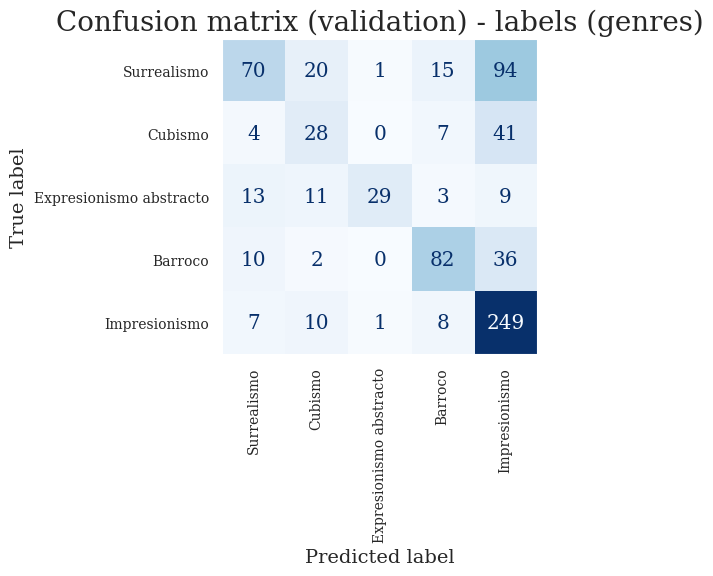

In [56]:
# === Cell 16: confusion matrix for labels (val) ===

cm_label = confusion_matrix(y_l_true, y_l_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_label, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) - labels (genres)")
plt.tight_layout()
plt.grid(False)
plt.show()


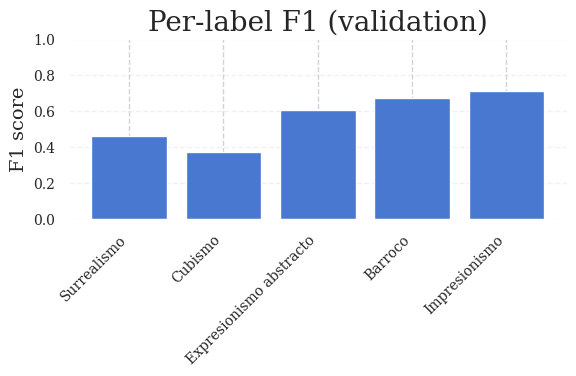

Surrealismo                   : F1 = 0.461
Cubismo                       : F1 = 0.371
Expresionismo abstracto       : F1 = 0.604
Barroco                       : F1 = 0.669
Impresionismo                 : F1 = 0.707


In [57]:
# === Cell 17: per-class F1 for labels ===

f1_per_label = f1_score(
    y_l_true,
    y_l_pred,
    average=None,
    labels=np.arange(NUM_LABELS),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_LABELS), f1_per_label)
plt.xticks(range(NUM_LABELS), class_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-label F1 (validation)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1_val in zip(class_names, f1_per_label):
    print(f"{name:30s}: F1 = {f1_val:.3f}")
